In [1]:
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
from sqlalchemy import create_engine

username = 'root'
password = '7999590423'
host = 'localhost'
port = '3306'
database = 'superstore_db'

engine = create_engine(
    f'mysql+pymysql://{username}:{password}@{host}:{port}/{database}'
)

In [3]:
with engine.connect() as conn:
    print('Connected to MYSQL successfully')

Connected to MYSQL successfully


In [4]:
## Data Reading :

query = """
SELECT 
   o.order_id,
    o.customer_id,
    o.product_id,
    o.order_date,
    o.ship_date,
    o.ship_mode,
    o.country,
    o.state,
    o.city,
    o.region,
    o.postal_code,
    o.sales,
    o.quantity,
    o.discount,
    o.profit,
    o.shipping_cost,

    p.product_name,
    p.category,
    p.sub_category,

    c.customer_name,
    c.segment,

    COALESCE(r.Returned,'No') AS returned,
    r.market

FROM orders o
JOIN products p
ON o.product_id = p.product_id

JOIN customers c
ON o.customer_id = c.customer_id

LEFT JOIN returns r
ON o.order_id = r.`Order ID`;
"""
df = pd.read_sql(query, engine)
df

,order_id,customer_id,product_id,order_date,ship_date,ship_mode,country,state,city,region,...,discount,profit,shipping_cost,product_name,category,sub_category,customer_name,segment,returned,market
0,CG-2014-7660,PH-8790,FUR-ADV-10000002,2014-05-08,2014-05-13,Standard Class,Democratic Republic of the Congo,Kinshasa,Kinshasa,Africa,...,0.0,40.26,6.11,"Advantus Photo Frame, Duo Pack",Furniture,Furnishings,Patricia Hirasaki,Home Office,No,None
1,IZ-2014-4660,TB-11190,FUR-ADV-10000002,2014-09-08,2014-09-15,Standard Class,Iraq,Baghdad,Baghdad,EMEA,...,0.0,20.13,4.03,"Advantus Photo Frame, Duo Pack",Furniture,Furnishings,Thomas Brumley,Home Office,No,None
2,RW-2012-8200,SG-10890,FUR-ADV-10000108,2012-02-20,2012-02-24,Standard Class,Rwanda,Kigali,Kigali,Africa,...,0.0,1.92,10.80,"Advantus Clock, Erganomic",Furniture,Furnishings,Susan Gilcrest,Corporate,No,None
3,LI-2011-9980,PM-9135,FUR-ADV-10000108,2011-04-13,2011-04-15,Second Class,Liberia,Montserrado,Monrovia,Africa,...,0.0,0.96,9.27,"Advantus Clock, Erganomic",Furniture,Furnishings,Peter McVee,Home Office,No,None
4,MO-2012-8110,AR-540,FUR-ADV-10000108,2012-05-10,2012-05-17,Standard Class,Morocco,Grand Casablanca,Casablanca,Africa,...,0.0,0.48,2.83,"Advantus Clock, Erganomic",Furniture,Furnishings,Andy Reiter,Consumer,No,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51290,MZ-2013-3540,EH-4005,TEC-STA-10004542,2013-04-19,2013-04-23,Standard Class,Mozambique,Sofala,Beira,Africa,...,0.0,12.00,4.68,"StarTech Calculator, Durable",Technology,Machines,Erica Hernandez,Home Office,No,None
51291,TU-2014-8160,SC-10260,TEC-STA-10004542,2014-07-07,2014-07-13,Standard Class,Turkey,Istanbul,Istanbul,EMEA,...,0.6,-18.05,1.62,"StarTech Calculator, Durable",Technology,Machines,Scott Cohen,Corporate,No,None
51292,TU-2011-790,CC-2145,TEC-STA-10004834,2011-11-03,2011-11-08,Standard Class,Turkey,Adana,Adana,EMEA,...,0.6,-107.83,13.61,"StarTech Receipt Printer, Red",Technology,Machines,Charles Crestani,Consumer,No,None
51293,NI-2013-7410,CD-1920,TEC-STA-10004834,2013-08-28,2013-09-03,Standard Class,Nigeria,Kano,Kano,Africa,...,0.7,-37.73,5.77,"StarTech Receipt Printer, Red",Technology,Machines,Carlos Daly,Consumer,No,None


In [5]:
 # Changing the data type of shipping_date and order_date column 

df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])


In [6]:
# # dropping the market column

df.drop(columns = ['market'], inplace = True)

# Shipping & Operation Analysis:

### Shipping time in days for each order 

In [7]:
query = """
SELECT 
    order_id,
    DATEDIFF(ship_date, order_date) AS shipping_days
FROM orders;
"""
shipping_time_by_orders = pd.read_sql(query, engine)

shipping_time_by_orders

,order_id,shipping_days
0,CA-2012-124891,0
1,IN-2013-77878,2
2,IN-2013-71249,1
3,ES-2013-1579342,2
4,SG-2013-4320,1
...,...,...
51285,KZ-2011-1240,2
51286,NI-2012-9890,0
51287,TU-2013-7830,4
51288,NI-2014-9730,4


### Average shipping time over all

In [8]:
query = """
SELECT 
    ROUND(AVG(DATEDIFF(ship_date, order_date)), 2) AS avg_shipping_days
FROM orders;
"""
average_shipping_time = pd.read_sql(query, engine)

average_shipping_time

,avg_shipping_days
0,3.97


### MAX and MIN shipping dates

In [9]:
query = """
SELECT 
    ROUND(MAX(DATEDIFF(ship_date, order_date)), 2) AS max_shipping_days,
    ROUND(MIN(DATEDIFF(ship_date, order_date)), 2) AS min_shipping_days
FROM orders;
"""
max_min_shipping_dates = pd.read_sql(query, engine)

max_min_shipping_dates

,max_shipping_days,min_shipping_days
0,7,0


### Shipping Method VS shipping cost

In [12]:
query = """
SELECT 
    ship_mode,
    ROUND(AVG(`shipping_Cost`),2) AS avg_shipping_cost
FROM orders
GROUP BY ship_mode
ORDER BY avg_shipping_cost DESC;
"""
Shipping_method_vs_shipping_cost = pd.read_sql(query, engine)

Shipping_method_vs_shipping_cost

,ship_mode,avg_shipping_cost
0,Same Day,42.95
1,First Class,41.06
2,Second Class,30.48
3,Standard Class,19.99


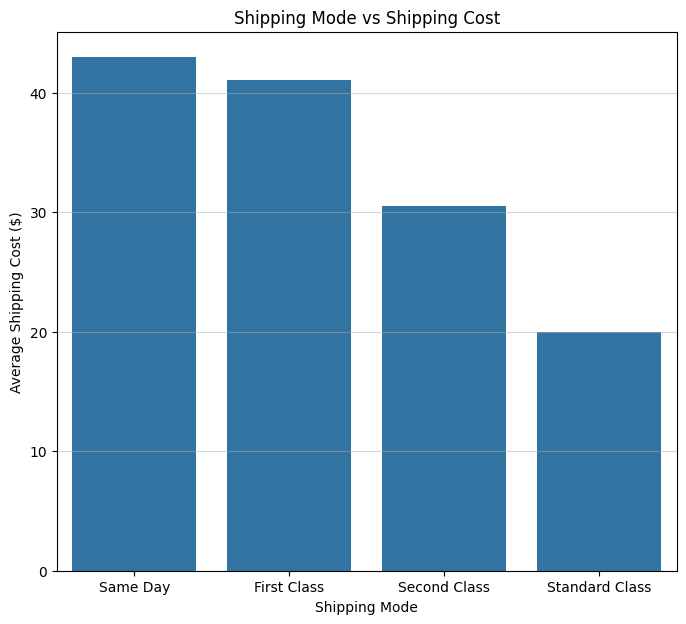

In [27]:
plt.figure(figsize = (8,7))

sns.barplot(x = 'ship_mode',
            y = 'avg_shipping_cost',
            data = Shipping_method_vs_shipping_cost
           )

plt.title('Shipping Mode vs Shipping Cost')
plt.xlabel('Shipping Mode')
plt.ylabel('Average Shipping Cost ($)')
plt.grid(axis = 'y', alpha = 0.5)

plt.show()


### Shipping mode vs Sales and profit

In [10]:
query = """
SELECT 
    ship_mode,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit
FROM orders
GROUP BY ship_mode
ORDER BY total_sales DESC;
"""
shipping_mode_against_sales_and_profit = pd.read_sql(query, engine)

shipping_mode_against_sales_and_profit

,ship_mode,total_sales,total_profit
0,Standard Class,7578655.51,890595.78
1,Second Class,2565672.42,292582.91
2,First Class,1830977.00,208104.63
3,Same Day,667202.32,76173.23


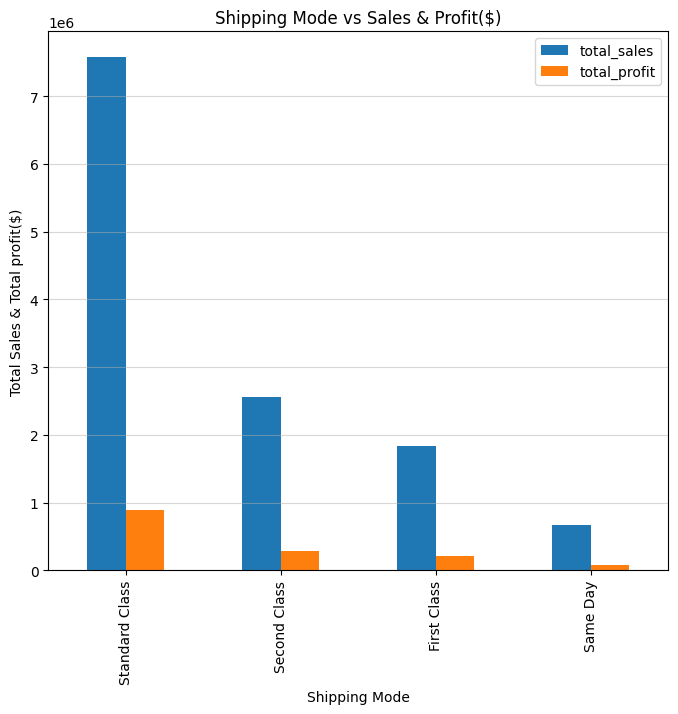

In [42]:
shipping_mode_against_sales_and_profit.plot(x = 'ship_mode',
                                       y = ['total_sales','total_profit'],
                                       kind = 'bar',
                                      figsize = (8,7)
)

plt.title('Shipping Mode vs Sales & Profit($)')
plt.xlabel('Shipping Mode')
plt.ylabel('Total Sales & Total profit($)')
plt.grid(axis = 'y', alpha = 0.5)

plt.show()


## Late shipment analysis :-

### How many orders took more than 5 days to ship?

In [16]:
query = """
SELECT 
    COUNT(*) AS late_shipments
FROM orders
WHERE DATEDIFF(ship_date, order_date) > 5;
"""
late_shipments = pd.read_sql(query, engine)

late_shipments

,late_shipments
0,9312


### Profit impact of late shipments

In [17]:
query = """
SELECT 
    CASE
        WHEN DATEDIFF(ship_date, order_date) > 5 THEN 'Late'
        ELSE 'On-Time'
    END AS shipment_status,
    ROUND(SUM(profit), 2) AS total_profit
FROM orders
GROUP BY shipment_status;
"""
impact_on_profit_of_late_shipments = pd.read_sql(query, engine)

impact_on_profit_of_late_shipments

,shipment_status,total_profit
0,On-Time,1197510.77
1,Late,269945.78


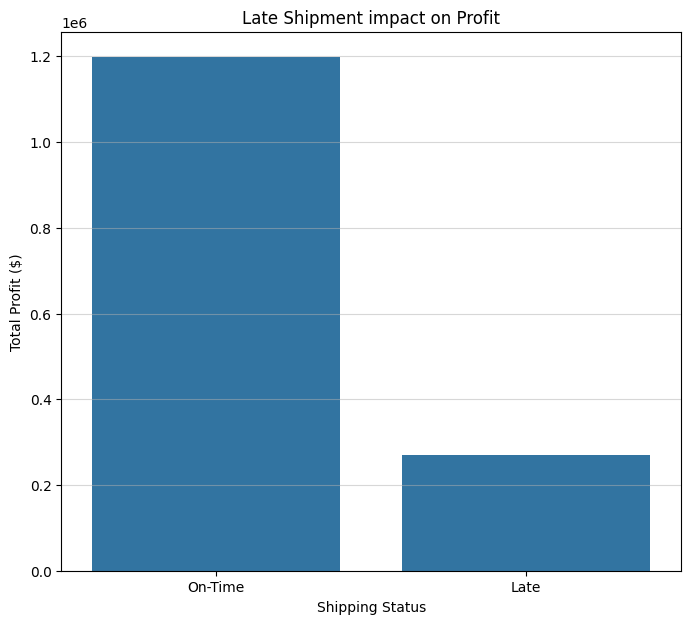

In [19]:
plt.figure(figsize = (8,7))

sns.barplot(x = 'shipment_status',
            y = 'total_profit',
            data = impact_on_profit_of_late_shipments
           )

plt.title('Late Shipment impact on Profit')
plt.xlabel('Shipping Status')
plt.ylabel('Total Profit ($)')
plt.grid(axis = 'y', alpha = 0.5)

plt.show()


### Late shipment by region 

In [20]:
query = """
SELECT 
    region, 
    COUNT(*) AS late_shipments
FROM orders
WHERE DATEDIFF(ship_date, order_date) > 5
GROUP BY region 
ORDER BY late_shipments DESC;
"""
late_shipment_by_region = pd.read_sql(query, engine)

late_shipment_by_region

,region,late_shipments
0,Central,2214
1,South,1146
2,North,922
3,EMEA,907
4,Africa,762
5,West,599
6,Oceania,594
7,Southeast Asia,551
8,East,496
9,North Asia,423


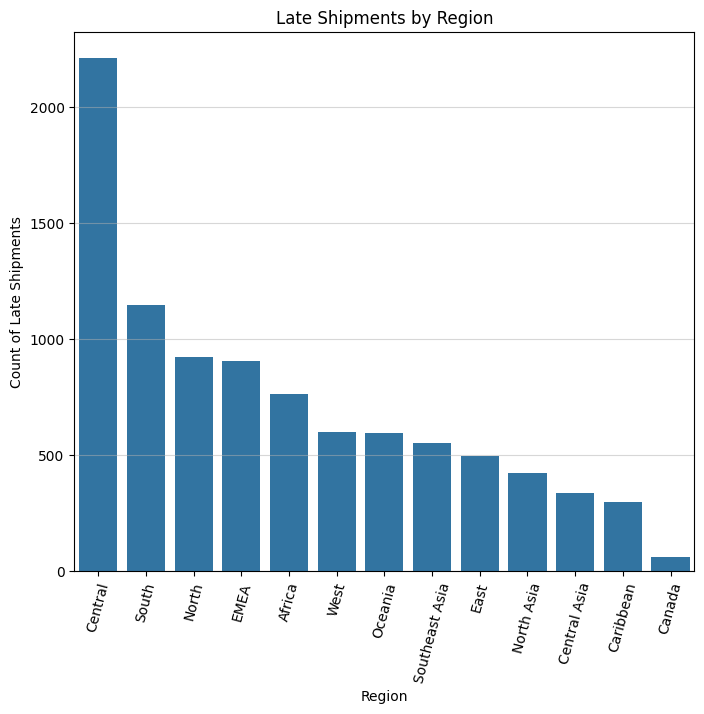

In [22]:
plt.figure(figsize = (8,7))

sns.barplot(x = 'region',
            y = 'late_shipments',
            data = late_shipment_by_region
           )

plt.title('Late Shipments by Region')
plt.xlabel('Region')
plt.ylabel('Count of Late Shipments')
plt.xticks(rotation = 75)
plt.grid(axis = 'y', alpha = 0.5)

plt.show()


### Shipping efficiency summary 

In [25]:
query = """
SELECT 
    ship_mode,
    COUNT(*) AS total_orders,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(AVG(DATEDIFF(ship_date, order_date)), 2) AS avg_shipping_days
FROM orders
GROUP BY ship_mode;
"""
shipping_efficiency_summary = pd.read_sql(query, engine)
shipping_efficiency_summary

,ship_mode,total_orders,total_profit,avg_shipping_days
0,Same Day,2701,76173.23,0.04
1,Second Class,10309,292582.91,3.23
2,First Class,7505,208104.63,2.18
3,Standard Class,30775,890595.78,5.00


### Average shipping time by shipping mode:

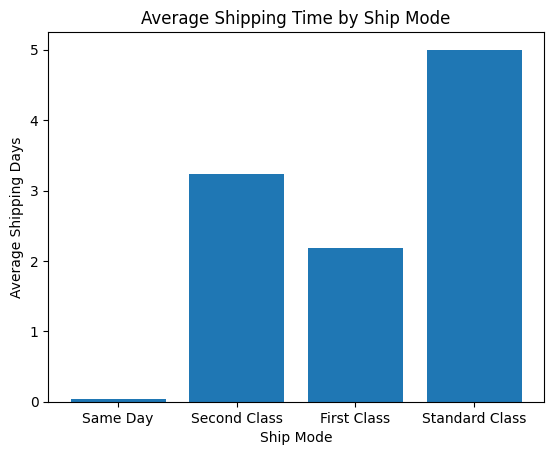

In [30]:
plt.figure()

plt.bar(
    shipping_efficiency_summary['ship_mode'],
    shipping_efficiency_summary['avg_shipping_days']
)

plt.xlabel('Ship Mode')
plt.ylabel('Average Shipping Days')
plt.title('Average Shipping Time by Ship Mode')

plt.show()

### Shipping cost vs Profit

In [28]:
query = """
SELECT
    ship_mode,
    ROUND(AVG(shipping_cost),2) AS avg_shipping_cost,
    ROUND(AVG(profit),2) AS avg_profit
FROM orders
GROUP BY ship_mode;
"""
shipping_cost_vs_profit = pd.read_sql(query, engine)

shipping_cost_vs_profit

,ship_mode,avg_shipping_cost,avg_profit
0,Same Day,42.95,28.20
1,Second Class,30.48,28.38
2,First Class,41.06,27.73
3,Standard Class,19.99,28.94


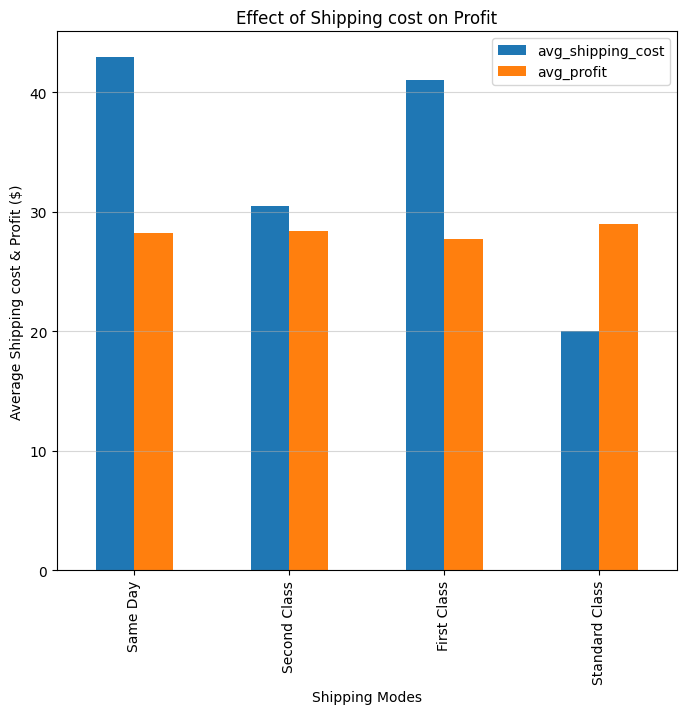

In [44]:
shipping_cost_vs_profit.plot(x = 'ship_mode',
                             y = ['avg_shipping_cost','avg_profit'],
                             kind = 'bar',
                             figsize = (8,7)
)

plt.title('Effect of Shipping cost on Profit')
plt.xlabel('Shipping Modes')
plt.ylabel('Average Shipping cost & Profit ($)')
plt.grid(axis = 'y', alpha = 0.5)

plt.show()


### Shipping cost by region:

In [32]:
query = """
SELECT 
	region,
    ROUND(AVG(shipping_cost),2) AS avg_shipping_cost
FROM orders
GROUP BY region
ORDER BY avg_shipping_cost DESC;
"""
shipping_cost_by_region = pd.read_sql(query, engine)

shipping_cost_by_region

,region,avg_shipping_cost
0,North Asia,40.67
1,Central Asia,38.01
2,Oceania,34.63
3,Southeast Asia,29.95
4,North,27.53
5,Central,26.71
6,East,25.56
7,South,25.36
8,West,23.89
9,Caribbean,21.06


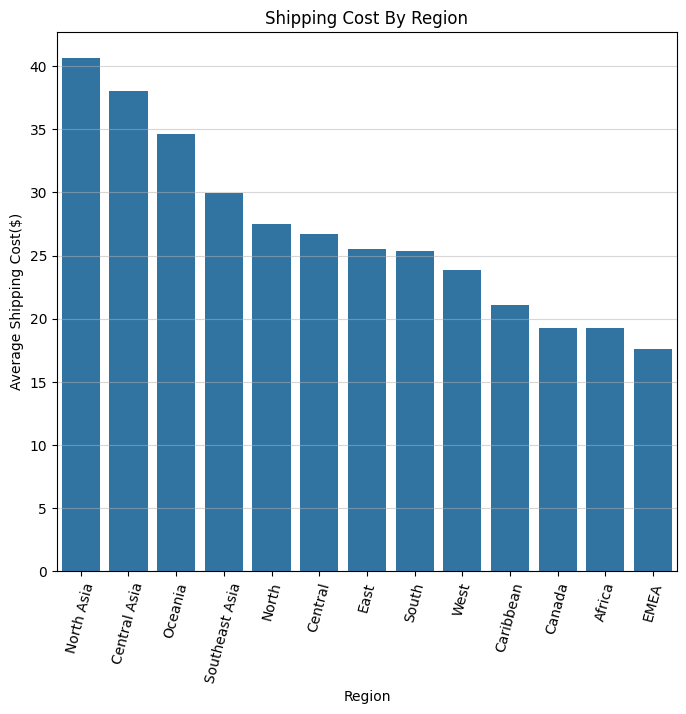

In [46]:
plt.figure(figsize = (8,7))

sns.barplot(x = 'region',
            y = 'avg_shipping_cost',
            data = shipping_cost_by_region
           )

plt.title('Shipping Cost By Region')
plt.xlabel('Region')
plt.ylabel('Average Shipping Cost($)')
plt.xticks(rotation = 75)
plt.grid(axis = 'y', alpha = 0.5)

plt.show()


# Summary:

## Key insight of Shipping and Operation Analysis

### 1. Shipping Times
* **The Average:** Most orders take about **3.97 days** (nearly 4 days) to ship after being ordered.
* **The Range:** The fastest orders ship on the **Same Day** (0 days), while the slowest can take up to **7 days**.
* **Late Shipments:** There are **9,312 orders** that took more than 5 days to ship. This is a large number that can affect customer happiness.

### 2. Shipping Modes and Cost
* **Standard Class is King:** Most sales and profits come from **Standard Class** shipping. Even though it is the slowest (taking about 5 days), it is the most popular because it is the cheapest for the customer.
* **The Cost of Speed:** **Same Day** shipping is the most expensive to provide (averaging over $40), while **Standard Class** is the cheapest (averaging $20).

### 3. Impact on Profit
* **Speed vs. Money:** Interestingly, even though "Same Day" shipping costs the company more, the **average profit** per order is quite similar across all shipping modes (around $28). 
* **The Late Penalty:** Orders that are shipped **Late** bring in much lower total profit compared to orders shipped **On-Time**. Efficiency in the warehouse directly saves money.

### 4. Regional Differences
* **North Asia** has the highest average shipping costs, while **EMEA** has the lowest.
* **Central Region** has the highest number of late shipments. This is likely because it is the busiest region with the most orders.

### 5. Key Takeaway
To improve operations, the company should focus on the **9,312 late shipments**, especially in the **Central region**. Reducing shipping time to under 5 days for these orders would significantly protect the company's total profit.